# Tournament predictions

In [1]:
#setup
from rugbyModels import *
np.random.seed(1)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

data= pd.read_csv("final_data_1.csv")
data["date"] = pd.to_datetime(data["date"])


#think its reasoable to combine these for models without dgs - shouldnt overwrite like this but made the descxision too late
data["home_penalties"] = data["home_penalties"]+data["home_drop_goals"] 
data["away_penalties"] = data["away_penalties"]+data["away_drop_goals"]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [home, sd_att, sd_def, att, def_, int_try, sd_dis_clean, sd_dis_force, dis_clean, dis_force, int_pen, p_conv]


Output()

Sampling 4 chains for 1_500 tune and 5_000 draw iterations (6_000 + 20_000 draws total) took 90 seconds.


=== Northern Hemisphere ===
          mean_pts  p_1st  p_top2  p_top3  p_top4  p_top5
France      23.467  0.588   0.814   0.927   0.986   0.999
Ireland     19.828  0.217   0.554   0.807   0.955   0.995
England     17.766  0.110   0.336   0.629   0.895   0.986
Scotland    16.948  0.080   0.267   0.540   0.860   0.978
Wales       10.778  0.006   0.026   0.086   0.254   0.769
Italy        6.432  0.000   0.002   0.011   0.050   0.274

=== Southern Hemisphere ===
              mean_pts  p_1st  p_top2  p_top3  p_top4  p_top5
All Blacks      21.934  0.467   0.830   0.954   0.992   1.000
South Africa    21.787  0.447   0.824   0.950   0.992   0.999
Argentina       14.844  0.050   0.190   0.547   0.842   0.973
Australia       13.373  0.029   0.121   0.398   0.757   0.955
Fiji             9.231  0.007   0.033   0.136   0.351   0.802
Japan            4.592  0.000   0.002   0.015   0.067   0.271


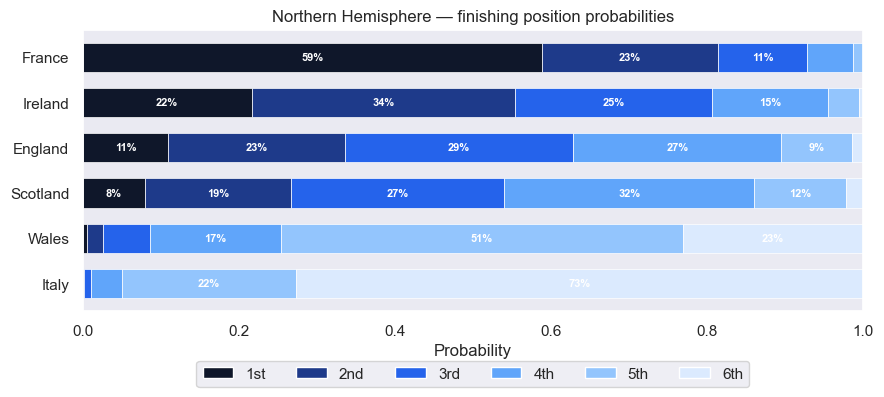

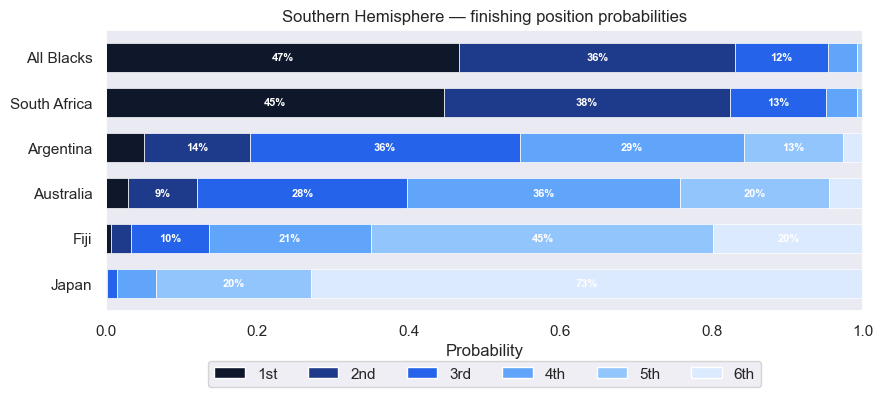

In [2]:
ncPred = PoissonModel(nSamples = 20000).fit(data) # fit model
NHtable,SHtable = ncPred.simulate_group() # simulate group stage

And if we assume these group placings, how will the finals go?

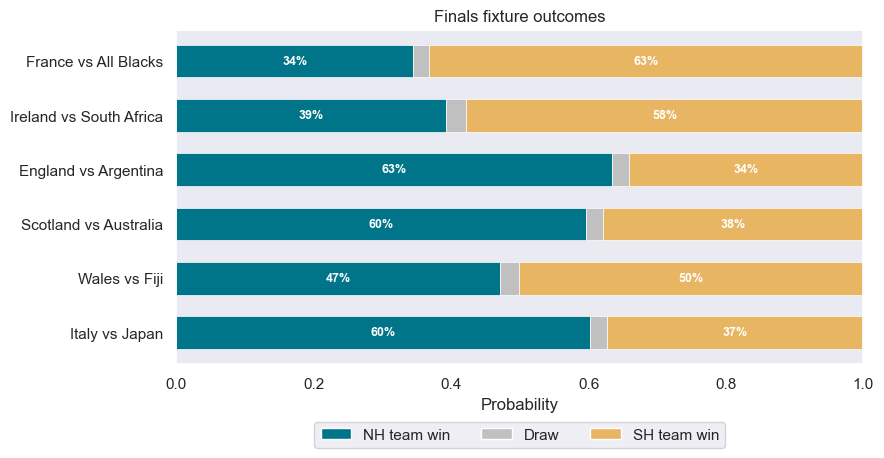

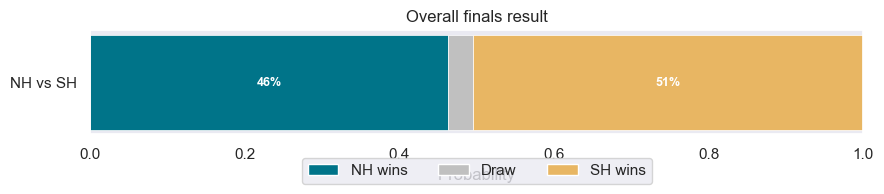

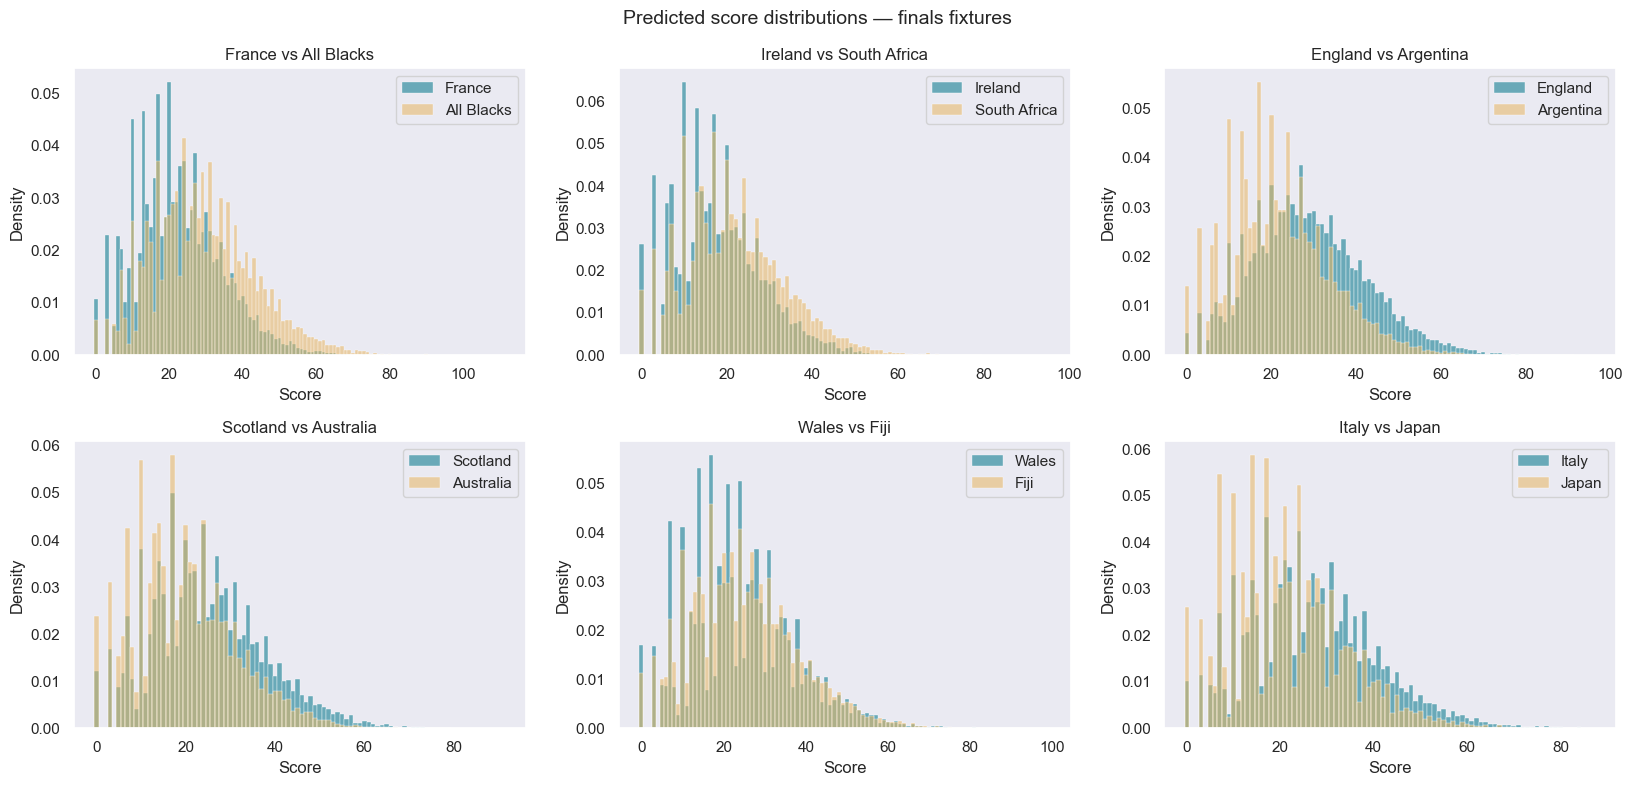

=== Finals fixtures ===
France vs All Blacks: P(North)=0.345  P(Draw)=0.023  P(South)=0.632
Ireland vs South Africa: P(North)=0.393  P(Draw)=0.029  P(South)=0.578
England vs Argentina: P(North)=0.635  P(Draw)=0.024  P(South)=0.341
Scotland vs Australia: P(North)=0.597  P(Draw)=0.025  P(South)=0.379
Wales vs Fiji: P(North)=0.472  P(Draw)=0.027  P(South)=0.501
Italy vs Japan: P(North)=0.602  P(Draw)=0.025  P(South)=0.374

Overall: P(NH wins=) = 0.463   P(Tie) = 0.032   P(SH wins=) = 0.505


In [3]:
_ = ncPred.simulate_finals(NHtable, SHtable)

And if we dont assume these placings and factor uncertainty over group stage positions into finals calculations?

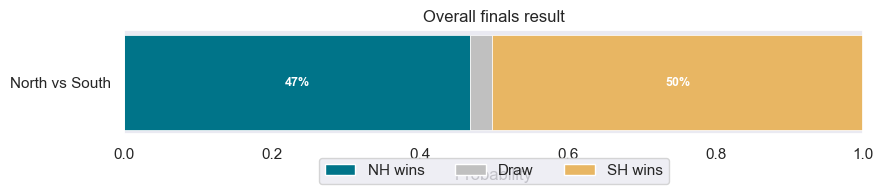

=== Finals  ===

Overall: P(North) = 0.468   P(Tie) = 0.030   P(South) = 0.502


In [4]:
_ = ncPred.simulate_finals_from_scratch()

Looking close!

----
# Pairwise win probabilitie
The probability of each team winning a home fixture against each other team.

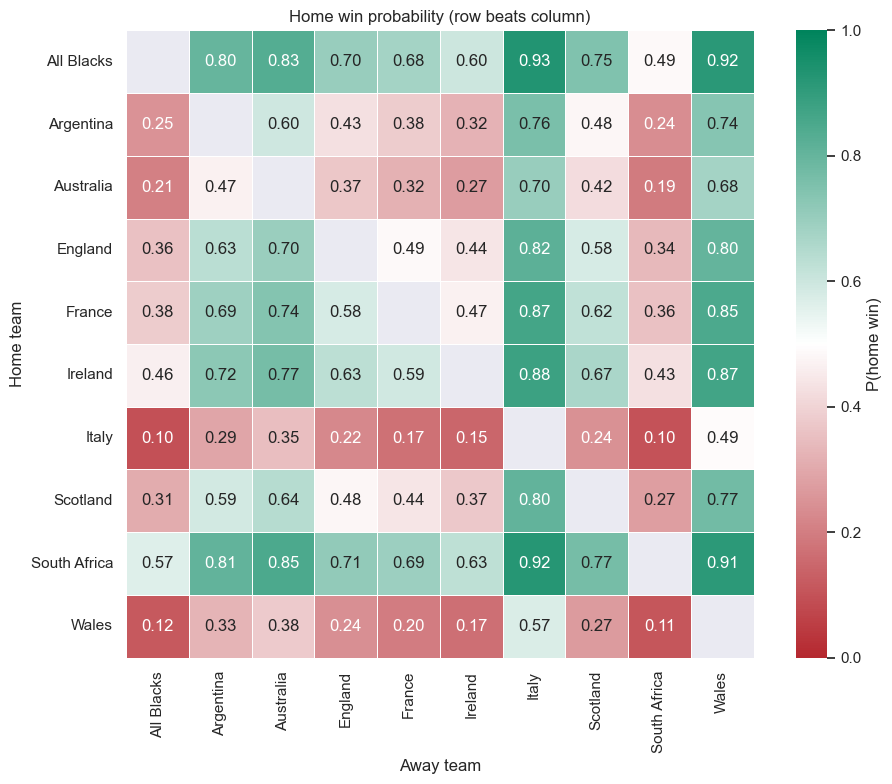

,All Blacks,Argentina,Australia,England,France,Ireland,Italy,Scotland,South Africa,Wales
All Blacks,NaN,0.79845,0.83330,0.70300,0.67625,0.60105,0.93330,0.74840,0.48560,0.91520
Argentina,0.24950,NaN,0.59710,0.42925,0.37895,0.32115,0.75965,0.47680,0.23695,0.73730
Australia,0.20635,0.46575,NaN,0.36930,0.32010,0.27115,0.70250,0.41905,0.19440,0.67810
England,0.35700,0.63315,0.69550,NaN,0.48555,0.43760,0.81935,0.57920,0.33840,0.80310
France,0.38245,0.68810,0.74080,0.58155,NaN,0.46815,0.86670,0.62165,0.35825,0.84955
Ireland,0.46345,0.72480,0.76810,0.62985,0.59220,NaN,0.88075,0.66630,0.42875,0.86750
Italy,0.09620,0.29125,0.34945,0.22305,0.17060,0.14800,NaN,0.24255,0.09945,0.49145
Scotland,0.30535,0.58900,0.64445,0.47850,0.44100,0.37275,0.80495,NaN,0.27415,0.77410
South Africa,0.56615,0.80765,0.84930,0.71445,0.69435,0.62655,0.92315,0.76685,NaN,0.91390
Wales,0.11610,0.32620,0.37845,0.24055,0.19885,0.16700,0.57085,0.26675,0.10840,NaN


In [5]:
ncPred.plot_pairwise_win_probs()

----
# Interpretability
What is driving each teams success/failure?

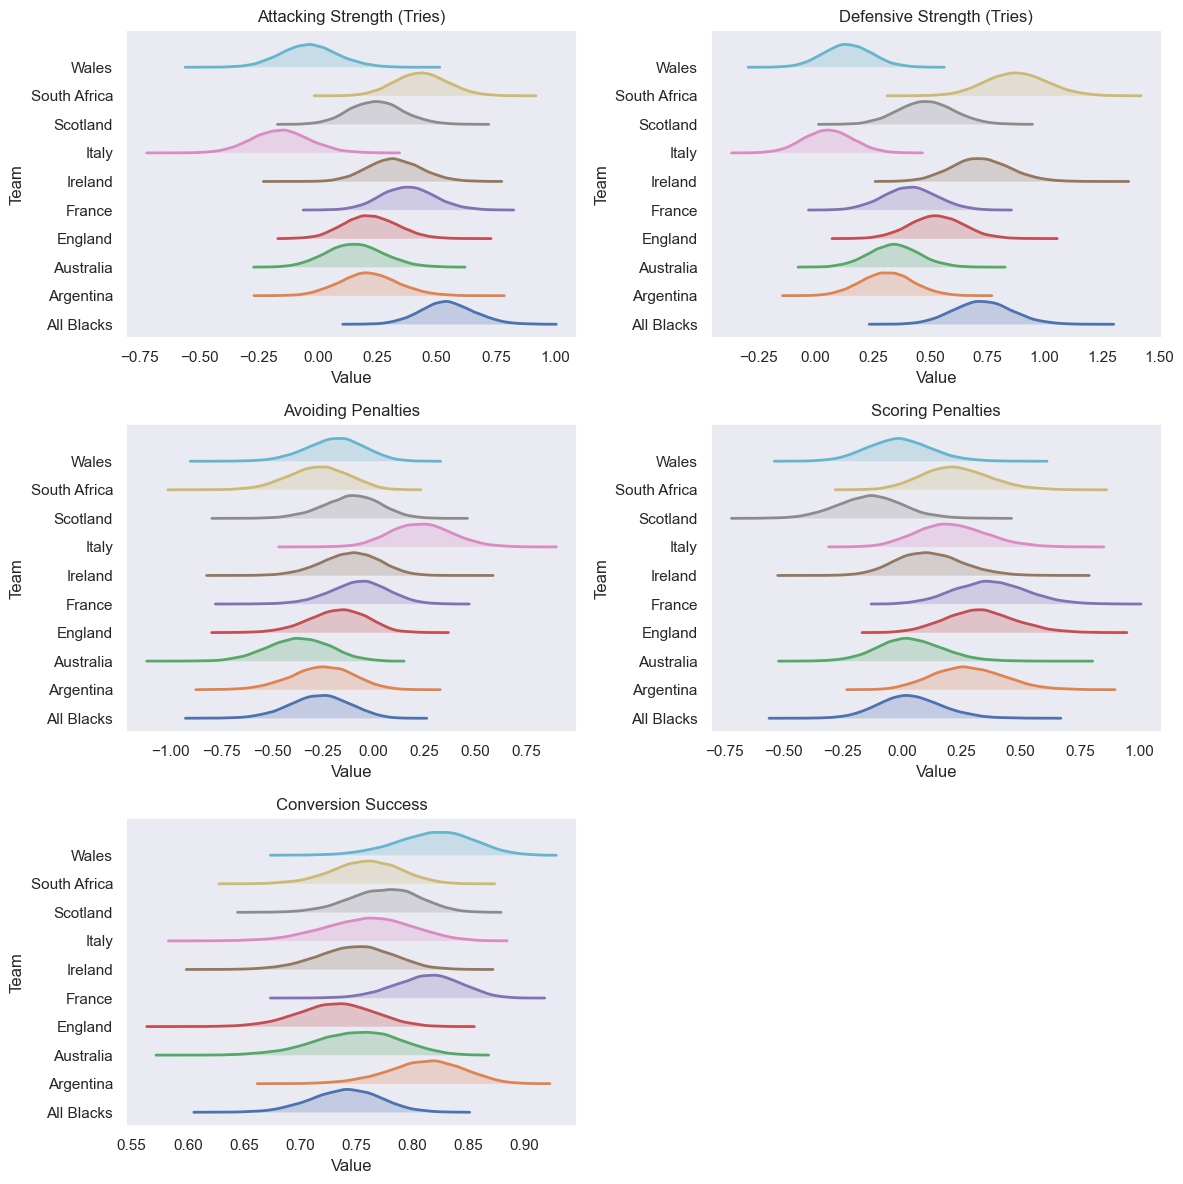

In [6]:
ncPred.plot_params()